<h1 style="text-align:center;">
Amazon delivery - EDA
</h1>

# 1. Problem definition
### The project begins with an exploratory data analysis of the dataset to understand its structure, data quality, and the relationships between key variables. Through this analysis, the study aims to identify patterns, trends, and potential correlations within the data related to delivery operations. The goal of this exploratory phase is to gain a clearer understanding of the dataset and the factors associated with delivery time before applying any further analytical or predictive methods.

### https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset/data

# 2. Data Loading

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from geopy.distance import geodesic

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sujalsuthar/amazon-delivery-dataset/amazon_delivery.csv


# 3. Data cleaning

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sujalsuthar/amazon-delivery-dataset/amazon_delivery.csv')
df_raw = df.copy()
df

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [4]:
df.describe(include='all')

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
count,43739,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739,43739,43739,43648,43739,43739,43739,43739.000000,43739
unique,43739,NaN,NaN,NaN,NaN,NaN,NaN,44,177,193,6,5,4,4,NaN,16
top,nsyz997960170,NaN,NaN,NaN,NaN,NaN,NaN,2022-03-15,21:55:00,21:30:00,Fog,Low,motorcycle,Metropolitian,NaN,Electronics
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,1141,460,481,7440,14999,25527,32698,NaN,2849
mean,NaN,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124.905645,NaN
std,NaN,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.915451,NaN
min,NaN,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN
25%,NaN,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,NaN
50%,NaN,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.000000,NaN
75%,NaN,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.000000,NaN


## Data quality table

In [5]:
# Data quality table
data_quality = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique()  # valori unice care exista in tabel
})

# Flags
data_quality["is_constant"] = data_quality["unique_values"] <= 1
data_quality["is_high_missing"] = data_quality["missing_percent"] > 30
data_quality["is_duplicate_col"] = df.T.duplicated().values

# Format percent
data_quality["missing_percent"] = data_quality["missing_percent"].astype(str) + "%"

data_quality

,dtype,missing_count,missing_percent,unique_values,is_constant,is_high_missing,is_duplicate_col
Order_ID,object,0,0.0%,43739,False,False,False
Agent_Age,int64,0,0.0%,22,False,False,False
Agent_Rating,float64,54,0.12%,28,False,False,False
Store_Latitude,float64,0,0.0%,521,False,False,False
Store_Longitude,float64,0,0.0%,415,False,False,False
Drop_Latitude,float64,0,0.0%,4367,False,False,False
Drop_Longitude,float64,0,0.0%,4367,False,False,False
Order_Date,object,0,0.0%,44,False,False,False
Order_Time,object,0,0.0%,177,False,False,False
Pickup_Time,object,0,0.0%,193,False,False,False


In [6]:
cat_cols = ["Weather", "Traffic", "Vehicle", "Area", "Category"]

# vezi valorile unice
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print()

# curățare spații
df[cat_cols] = df[cat_cols].apply(lambda x: x.astype("string").str.strip())

# transformăm toate variantele de nan în NA
df[cat_cols] = df[cat_cols].replace(["NaN", "nan", "NAN", "None", "null"], pd.NA)

# înlocuim valorile lipsă
df[cat_cols] = df[cat_cols].fillna("Missing")

Weather
['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]

Traffic
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

Vehicle
['motorcycle ' 'scooter ' 'van' 'bicycle ']

Area
['Urban ' 'Metropolitian ' 'Semi-Urban ' 'Other']

Category
['Clothing' 'Electronics' 'Sports' 'Cosmetics' 'Toys' 'Snacks' 'Shoes'
 'Apparel' 'Jewelry' 'Outdoors' 'Grocery' 'Books' 'Kitchen' 'Home'
 'Pet Supplies' 'Skincare']



In [7]:
df["Traffic"].value_counts(dropna=False)

Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
Missing       91
Name: count, dtype: Int64

In [8]:
def calculate_distance(row):
    start = (row['Store_Latitude'], row['Store_Longitude'])
    end = (row['Drop_Latitude'], row['Drop_Longitude'])
    return geodesic(start, end).km
df.loc[:, 'Distance'] = df.apply(calculate_distance, axis=1)
# Distance in km

In [9]:
# Eliminate unuseful columns
df = df.drop(columns=[
    'Store_Latitude',
    'Store_Longitude',
    'Drop_Latitude',
    'Drop_Longitude'
])
df.head()

,Order_ID,Agent_Age,Agent_Rating,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance
0,ialx566343618,37,4.9,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.020737
1,akqg208421122,34,4.5,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.143737
2,njpu434582536,23,4.4,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.549693
3,rjto796129700,38,4.7,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.774497
4,zguw716275638,32,4.6,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.197898


In [10]:
# What time period does the data cover?
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(df['Order_Date'].min())
print(df['Order_Date'].max())

2022-02-11 00:00:00
2022-04-06 00:00:00


In [11]:
# calculate pickup time

# curățare + conversie
df['Pickup_Time'] = pd.to_timedelta(df['Pickup_Time'].astype(str).str.strip(), errors='coerce')
df['Order_Time'] = pd.to_timedelta(df['Order_Time'].astype(str).str.strip(), errors='coerce')

# diferența
diff = df['Pickup_Time'] - df['Order_Time']

# corecție pentru trecerea la ziua următoare
diff = diff.mask(diff < pd.Timedelta(0), diff + pd.Timedelta(days=1))

# minute
df['pickup_relative_time'] = diff.dt.total_seconds() / 60
df.head()

,Order_ID,Agent_Age,Agent_Rating,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance,pickup_relative_time
0,ialx566343618,37,4.9,2022-03-19,0 days 11:30:00,0 days 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.020737,15.0
1,akqg208421122,34,4.5,2022-03-25,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.143737,5.0
2,njpu434582536,23,4.4,2022-03-19,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.549693,15.0
3,rjto796129700,38,4.7,2022-04-05,0 days 18:00:00,0 days 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.774497,10.0
4,zguw716275638,32,4.6,2022-03-26,0 days 13:30:00,0 days 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.197898,15.0


In [12]:
# Eliminate unuseful columns
df = df.drop(columns=[
    'Order_Date',
    'Order_Time',
    'Pickup_Time',
    'Order_ID'
])
df.head()

,Agent_Age,Agent_Rating,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance,pickup_relative_time
0,37,4.9,Sunny,High,motorcycle,Urban,120,Clothing,3.020737,15.0
1,34,4.5,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.143737,5.0
2,23,4.4,Sandstorms,Low,motorcycle,Urban,130,Sports,1.549693,15.0
3,38,4.7,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.774497,10.0
4,32,4.6,Cloudy,High,scooter,Metropolitian,150,Toys,6.197898,15.0


# 4. Exploratory Data Analysis (EDA)

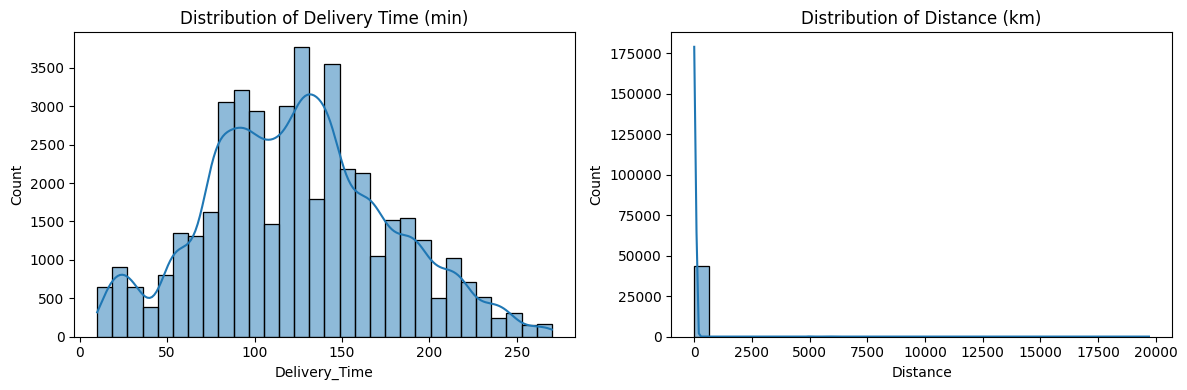

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df["Delivery_Time"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Delivery Time (min)")

sns.histplot(df["Distance"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Distance (km)")

plt.tight_layout()
plt.show()

In [14]:
bins = pd.cut(df["Distance"], bins=10)

distance_distribution = pd.DataFrame({
    "Count": bins.value_counts().sort_index(),
    "Percent": bins.value_counts(normalize=True).sort_index()*100
})

print(distance_distribution)

                        Count    Percent
Distance                                
(-18.244, 1972.275]     43551  99.570178
(1972.275, 3943.086]       40   0.091452
(3943.086, 5913.897]       89   0.203480
(5913.897, 7884.709]       32   0.073161
(7884.709, 9855.52]         0   0.000000
(9855.52, 11826.331]        0   0.000000
(11826.331, 13797.142]      0   0.000000
(13797.142, 15767.953]      0   0.000000
(15767.953, 17738.764]     17   0.038867
(17738.764, 19709.576]     10   0.022863


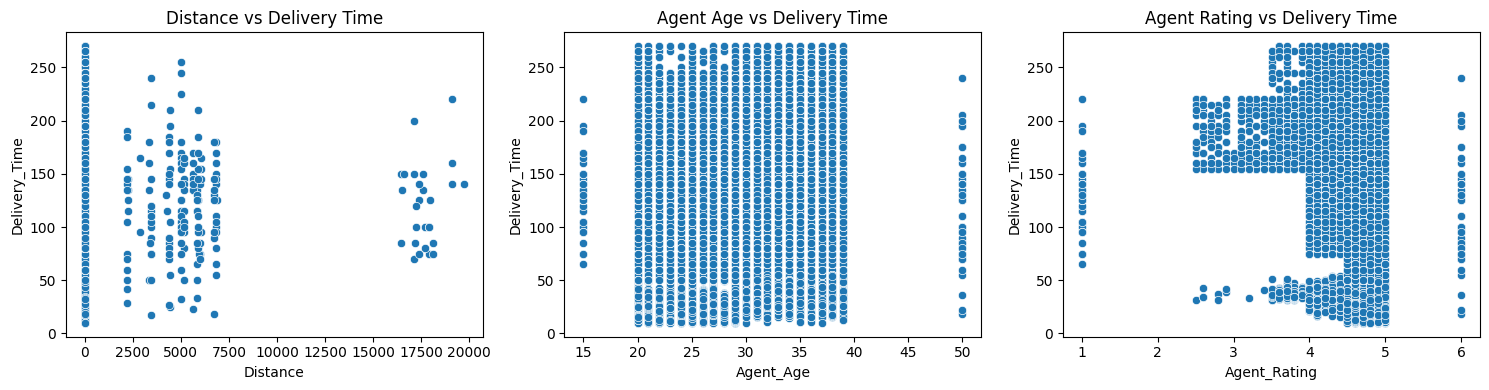

In [15]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.scatterplot(x="Distance", y="Delivery_Time", data=df, ax=axes[0])
axes[0].set_title("Distance vs Delivery Time")

sns.scatterplot(x="Agent_Age", y="Delivery_Time", data=df, ax=axes[1])
axes[1].set_title("Agent Age vs Delivery Time")

sns.scatterplot(x="Agent_Rating", y="Delivery_Time", data=df, ax=axes[2])
axes[2].set_title("Agent Rating vs Delivery Time")

plt.tight_layout()
plt.show()

### First of all, the dataset contains inconsistencies in the latitude and longitude values. Some calculated distances reach thousands of kilometers, which is not realistic for delivery operations within the given time frame. It is therefore likely that certain coordinate values are incorrect or represent outliers in the data. Additionally, the variables Agent Age and Agent Rating appear to have little influence on the delivery time and may be less relevant for explaining variations in delivery performance.

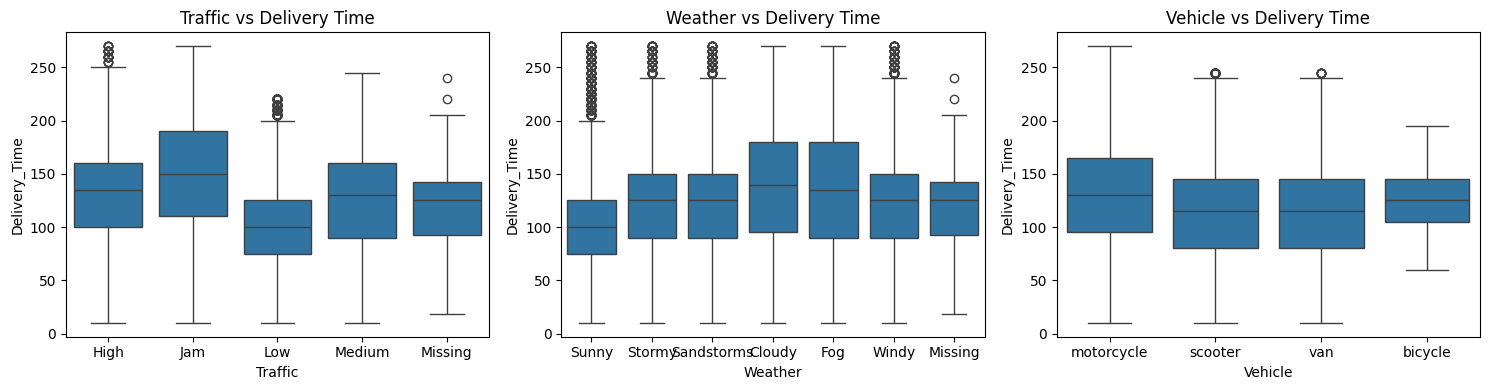

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.boxplot(x="Traffic", y="Delivery_Time", data=df, ax=axes[0])
axes[0].set_title("Traffic vs Delivery Time")

sns.boxplot(x="Weather", y="Delivery_Time", data=df, ax=axes[1])
axes[1].set_title("Weather vs Delivery Time")

sns.boxplot(x="Vehicle", y="Delivery_Time", data=df, ax=axes[2])
axes[2].set_title("Vehicle vs Delivery Time")

plt.tight_layout()
plt.show()

It appears that, regardless of the vehicle type, the delivery time remains within a similar range.

### Next: What"s the correlation between difeferent columns and categories?

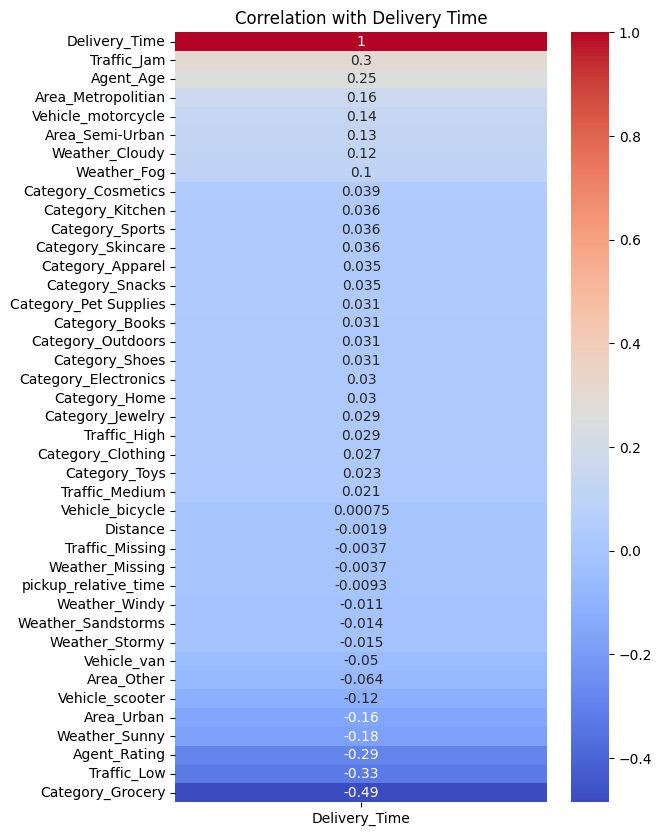

In [17]:
# coloane numerice
num_cols = [
    "Agent_Age",
    "Agent_Rating",
    "Distance",
    "pickup_relative_time",
    "Delivery_Time"
]

# coloane categorice relevante
cat_cols = [
    "Weather",
    "Traffic",
    "Vehicle",
    "Area",
    "Category"
]

# encoder sklearn
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# combinăm datele
data = pd.concat([df[num_cols].reset_index(drop=True), encoded_df], axis=1)

corr_delivery = data.corr()[["Delivery_Time"]].sort_values(by="Delivery_Time", ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(corr_delivery, annot=True, cmap="coolwarm")
plt.title("Correlation with Delivery Time")
plt.show()

In [18]:
pivot = df.pivot_table(
    values="Delivery_Time",
    index="Vehicle",
    columns="Traffic",
    aggfunc="mean"
)

print(pivot)

Traffic           High         Jam         Low      Medium     Missing
Vehicle                                                               
bicycle            NaN         NaN         NaN         NaN  127.000000
motorcycle  136.926058  155.630653  105.696633  133.062973  133.125000
scooter     118.245626  137.510486   95.178836  117.814575  123.343750
van         120.553254  134.373684   95.053435  119.249711  112.888889


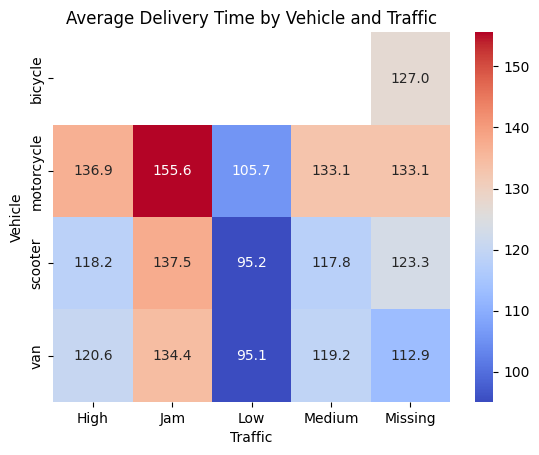

In [19]:
sns.heatmap(pivot, annot=True, cmap="coolwarm",fmt=".1f")
plt.title("Average Delivery Time by Vehicle and Traffic")
plt.show()

In [20]:
pivot = df.pivot_table(
    values="Delivery_Time",
    index="Vehicle",
    columns="Weather",
    aggfunc="mean"
)

print(pivot)

Weather         Cloudy         Fog     Missing  Sandstorms      Stormy  \
Vehicle                                                                  
bicycle            NaN         NaN  127.000000         NaN         NaN   
motorcycle  142.238354  140.651883  133.125000  130.426284  129.521244   
scooter     133.185680  131.217479  123.343750  113.203864  114.388597   
van         131.299830  129.605096  112.888889  112.452297  114.196970   

Weather          Sunny       Windy  
Vehicle                             
bicycle            NaN         NaN  
motorcycle  111.831360  130.880300  
scooter      91.999578  112.800336  
van          92.839161  114.960000  


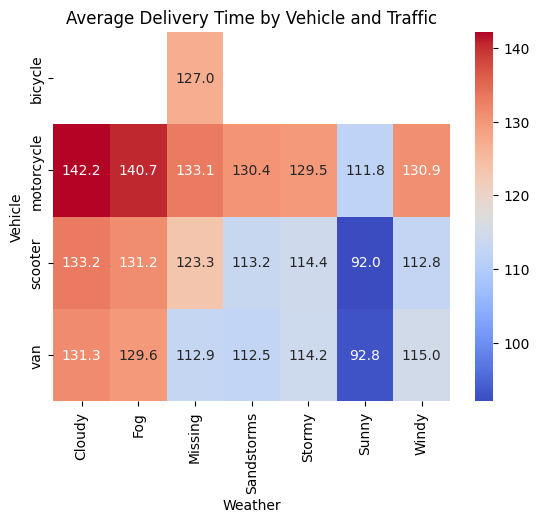

In [21]:
sns.heatmap(pivot, annot=True, cmap="coolwarm",fmt=".1f")
plt.title("Average Delivery Time by Vehicle and Traffic")
plt.show()

### How can be deen the most influencial factor is Traffic

# 5. Conclusions

### There are several factors that influence delivery time. The most important factor is distance. However, some inconsistencies were identified in the latitude and longitude data, which produce unrealistic distances and suggest the presence of outliers or incorrect geographic coordinates.

### Another important factor is traffic conditions. Heavy or jammed traffic can significantly slow down deliveries, even for motorcycles, which are generally more flexible in congested urban environments.

### There are also some concerns regarding the authenticity and reliability of certain parts of the dataset. The analysis suggests that delivery times appear relatively similar across different vehicle types, which raises questions about whether the vehicle variable has a strong impact on delivery performance in this dataset.
